# `eq` — quickstart notebook

End-to-end walkthrough of the `eqlib` Python wrapper:

1. Load the library (`Eq()` context manager)
2. Configure the equilibrium (`set_param`, `set_param_str`)
3. Pre-run validation (`validate()`, PR #164 / #165)
4. Solve (`run(mode=1)` — EQDSK-driven workflow)
5. Inspect the resulting `EqState` and plot ψ-surface profiles

Corresponds to the `eq` chapter (en: `eq/index.md`, ja: `eq/index.md`).
The notebook executes inside `test_run/test_output/eq_iter01/` so the
ITER equilibrium fixture `eqdata.ITER01` resolves to an on-disk file.


## 1. Locate the repo and import `eqlib`

The next cell adds `<repo>/python/` to `sys.path` so the notebook can
import `eqlib` regardless of where it was executed from. Lookup order:

1. `TASK_ROOT` environment variable, if set.
2. Walk up from the current working directory until a parent containing
   `python/eqlib/__init__.py` is found.

If neither locates the repo the cell raises a clear `RuntimeError`
instead of silently importing from a wrong path.

In [1]:
import os, pathlib, sys

def _find_task_python():
    env = os.environ.get('TASK_ROOT')
    if env:
        cand = pathlib.Path(env).expanduser() / 'python'
        if (cand / 'eqlib' / '__init__.py').is_file():
            return cand
    for anc in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
        marker = anc / 'python' / 'eqlib' / '__init__.py'
        if marker.is_file():
            return marker.parents[1]
    raise RuntimeError(
        'Could not locate the TASK repository python/ directory. '
        'Set TASK_ROOT=/path/to/task-repo or run this notebook from '
        'within a clone of the repo.'
    )

sys.path.insert(0, str(_find_task_python()))
from eqlib import Eq, EqDiagCode
print('eqlib imported')

eqlib imported


## 2. Configure an EQDSK-driven equilibrium

`eq.run()` defaults to `mode=1`, which calls `eq_load` to read
`KNAMEQ` and build the equilibrium. Geometry modes supported by
`eq_load` are `MODELG = 3, 5, 8, 9, 15`. The ITER fixture uses
`MODELG=3`.

In [2]:
eq = Eq()
eq.__enter__()

eq.set_param('RR',     6.5)    # major radius [m]
eq.set_param('BB',     5.3)    # toroidal field [T]
eq.set_param('RIP',    1.5)    # plasma current [MA]
eq.set_param('MODELG', 3)      # EQDSK path
eq.set_param_str('KNAMEQ', 'eqdata.ITER01')
print('parameters set')

parameters set


## 3. Pre-run validation — the two layers

`eq` has the same two-layer validation model as `tr`:

1. **`set_param` at call time** — unknown names, bad indices,
   out-of-range scalars are rejected synchronously.
2. **`validate()` before `run`** — cross-parameter consistency such
   as `KNAMEQ` missing when `MODELG` requires an EQDSK file.

### Layer 2 demo — blank `KNAMEQ`

Temporarily blank the filename so `validate()` reports `FILE_MISSING`,
then restore it.

In [3]:
eq.set_param_str('KNAMEQ', '')
diags = eq.validate()
print(f'blank KNAMEQ: {len(diags)} diagnostic(s)')
for d in diags:
    print(f'  [{EqDiagCode(d.code).name}] {d.param}: {d.message}')

eq.set_param_str('KNAMEQ', 'eqdata.ITER01')
assert eq.validate() == [], 'unexpectedly still has diagnostics'
print('validation clean again')

blank KNAMEQ: 1 diagnostic(s)
  [FILE_MISSING] KNAMEQ: MODELG=3/5/8 requires non-blank KNAMEQ (eqdata file)
validation clean again


## 4. Solve the equilibrium

In [4]:
eq.run()                 # mode=1 (EQDSK)
print('solve finished')

 # OLD FILE (eqdata.ITER01) IS ASSIGNED FOR INPUT.
solve finished


## 5. Inspect scalar results

In [5]:
state = eq.get_state()
print(f'nrgmax x nzgmax grid: {state.nrgmax} x {state.nzgmax}')
print(f'ψ-surface samples   : {state.npsmax}')
print(f'raxis  = {state.scalars["raxis"]:.4f} m')
print(f'zaxis  = {state.scalars["zaxis"]:.4f} m')
print(f'qaxis  = {state.scalars["qaxis"]:.4f}')
print(f'qsurf  = {state.scalars["qsurf"]:.4f}')
print(f'betat  = {state.scalars["betat"]:.4g}')
print(f'betap  = {state.scalars["betap"]:.4g}')
print(f'pvol   = {state.scalars["pvol"]:.4g} m^3')

nrgmax x nzgmax grid: 33 x 33
ψ-surface samples   : 21
raxis  = 6.3415 m
zaxis  = -0.0000 m
qaxis  = 0.5784
qsurf  = 3.3252
betat  = 0.01614
betap  = 0.3819
pvol   = 798 m^3


## 6. Plot ψ-surface profiles

`state.psips` (normalised flux), `state.ppps` (pressure),
`state.qqps` (safety factor), `state.ttps` (R·Bφ) are all indexed
over the `npsmax` ψ-surfaces.

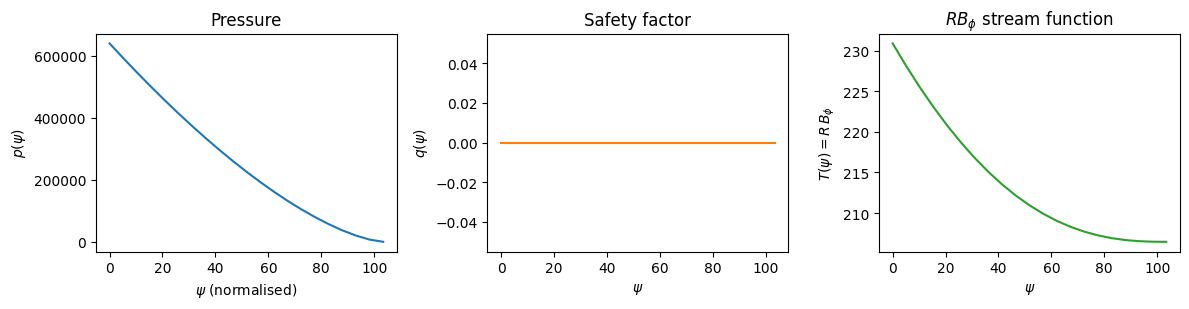

In [6]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from io import BytesIO
from IPython.display import Image, display

psi = list(state.psips)
pp  = list(state.ppps)
qq  = list(state.qqps)
tt  = list(state.ttps)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
axes[0].plot(psi, pp, 'C0-')
axes[0].set_xlabel(r'$\psi$ (normalised)')
axes[0].set_ylabel(r'$p(\psi)$')
axes[0].set_title('Pressure')

axes[1].plot(psi, qq, 'C1-')
axes[1].set_xlabel(r'$\psi$')
axes[1].set_ylabel(r'$q(\psi)$')
axes[1].set_title('Safety factor')

axes[2].plot(psi, tt, 'C2-')
axes[2].set_xlabel(r'$\psi$')
axes[2].set_ylabel(r'$T(\psi) = R\,B_\phi$')
axes[2].set_title(r'$R B_\phi$ stream function')

plt.tight_layout()

buf = BytesIO()
fig.savefig(buf, format='png', dpi=100, bbox_inches='tight')
plt.close(fig)
display(Image(data=buf.getvalue()))

## 7. Clean up

In [7]:
eq.close()
print('closed')

closed


## Next steps

- See `api-reference` in the same chapter for the full autodoc
  listing of `eqlib.Eq`, `eqlib.EqState`, and the exception
  hierarchy.
- Equivalent standalone scripts:
  `python/eqlib/examples/quickstart.py` and
  `python/eqlib/examples/parameter_sweep.py`.
- To drive `eq` from an LLM, see the MCP server
  `python/mcp-servers/eq_mcp/`.
